# Netective Properties Dataframe

### Imports

In [3]:
import pandas as pd
from netective import properties
import inspect
import networkx as nx
from freyrelab.nets.paths2 import ShortestPaths, Efficiency, ShortestDistances
from freyrelab.regnets.regnet import RegNet
import numpy as np
import seaborn as sb

### Fxns auxiliares

In [4]:
def remove_self_loops(G: nx.DiGraph):
    print(type(G))
    G.remove_edges_from(nx.selfloop_edges(G))

def normalize_props(total_instances, G, norm=None):
    norm_scalar_values = {}
    norm_dist_values = {}
    for name, x in total_instances.items():
        dict_ = (
            norm_scalar_values
            if x._return_type == "scalar"
            else norm_dist_values
        )
        try:
            if norm == "network":
                dict_[name] = x.norm_network()
            elif norm == "biological":
                dict_[name] = x.norm_biol()
        except (NotImplementedError, properties.NormalizationError):
            dict_[name] = np.nan

    return norm_scalar_values, norm_dist_values

### Obtención de objetos properties

In [6]:
parent_class = properties._Property

In [8]:
def get_child_classes(parent_class):
    child_classes = []
    for name, obj in inspect.getmembers(properties):
        if (
            inspect.isclass(obj)
            and issubclass(obj, parent_class)
            and obj != parent_class
        ):
            child_classes.append(obj)
    return child_classes

child_classes = get_child_classes(parent_class)

### Creación de Dataframe

#### Dummy network

In [9]:
G = RegNet()
n_nodes = 40
G.add_nodes_from(range(n_nodes))
G.add_edges_from([(i,j) for i in range(n_nodes) for j in range(n_nodes)])

#### Creación de instancias

In [10]:
def get_instances_no_paths(G, child_classes):
    instances = {x.__name__: x(G) for x in child_classes if not x._use_paths}
    return instances

def get_instances_paths(G, child_classes, net_shortest_paths, net_shortest_distances):
    instances = {x.__name__: x(G, net_shortest_paths = net_shortest_paths, net_shortest_distances = net_shortest_distances) for x in child_classes if x._use_paths}
    return instances

In [11]:
# Properties that do not use paths object
instances = get_instances_no_paths(G, child_classes)
    
# Objetos paths
remove_self_loops(G)
G = G.giant_component
G = G.to_undirected()
net_shortest_paths = ShortestPaths(G)
net_shortest_distances = ShortestDistances(G)
    
# Properties that use paths object
# They use the giant component from an undirected graph with no selfloops
instances_paths = get_instances_paths(G, child_classes, net_shortest_paths, net_shortest_distances)

<class 'freyrelab.regnets.regnet.RegNet'>


In [12]:
instances.update(instances_paths)

In [13]:
instances

{'AverageClusteringCoefficient': <netective.properties.AverageClusteringCoefficient at 0x22b0b2cb070>,
 'AverageDegreeNearestNeighbors': <netective.properties.AverageDegreeNearestNeighbors at 0x22b13966cd0>,
 'AverageOutDegreeNearestNeighbors': <netective.properties.AverageOutDegreeNearestNeighbors at 0x22b13966ee0>,
 'ClusteringCoefficient': <netective.properties.ClusteringCoefficient at 0x22b13966dc0>,
 'ComplexFeedForwardCircuits': <netective.properties.ComplexFeedForwardCircuits at 0x22b13966b20>,
 'Density': <netective.properties.Density at 0x22b13966970>,
 'EntropyPKout': <netective.properties.EntropyPKout at 0x22b13966df0>,
 'FeedbackLoops_3': <netective.properties.FeedbackLoops_3 at 0x22b13966eb0>,
 'GenesintheGiantComponent': <netective.properties.GenesintheGiantComponent at 0x22b13966d90>,
 'GiniIndex': <netective.properties.GiniIndex at 0x22b13966790>,
 'InDegree': <netective.properties.InDegree at 0x22b13966760>,
 'LocalityIndex': <netective.properties.LocalityIndex at 0x22

#### Diccionario

In [14]:
#   - @use_direction
#   - @use_selfloops
#   - @use_giant_component
#   - @use_paths
#   - @return_scalar
#   - @return_distribution
properties_info = {

    'Name' : [],
    'Selfloops' : [],
    'Directed networks' : [], 
    'Giant component' : [],
    'Uses object paths' : [],
    'Return scalar' : [],
    'Return a distribution' : []
}

In [16]:
for object in instances.values():
    properties_info['Name'].append(object.CLASS_NAME)
    properties_info['Selfloops'].append(object._use_selfloops)
    properties_info['Directed networks'].append(object._use_direction)
    properties_info['Giant component'].append(object._use_giant_component)
    properties_info['Uses object paths'].append(object._use_paths)
    if object._return_type == 'scalar':
        properties_info['Return scalar'].append(True)
        properties_info['Return a distribution'].append(False)
    else:
        properties_info['Return scalar'].append(False)
        properties_info['Return a distribution'].append(True)

#### Dataframe

In [17]:
properties_df = pd.DataFrame.from_dict(properties_info)

In [30]:
properties_df.loc[properties_df['Return scalar'] == True]

,Name,Selfloops,Directed networks,Giant component,Uses object paths,Return scalar,Return a distribution
0,Average Clustering Coefficient,False,False,False,False,True,False
4,Complex Feed-Forward Circuits,False,True,False,False,True,False
5,Density,True,True,True,False,True,False
6,Entropy of Degree Distribution,True,True,False,False,True,False
7,3-Feedback Loops,False,True,False,False,True,False
8,Gene % in the Giant Component,False,False,True,False,True,False
9,Gini Index,True,True,False,False,True,False
12,Max In-Dregree,True,True,False,False,True,False
13,Max Out-Degree,True,True,False,False,True,False
15,Regulators,True,True,False,False,True,False


In [19]:
properties = properties_df.replace(False, 0)
properties = properties.replace(True, 1)

In [20]:
properties = properties.set_index('Name')

In [21]:
foo = properties.T

In [22]:
buena = foo.corr()

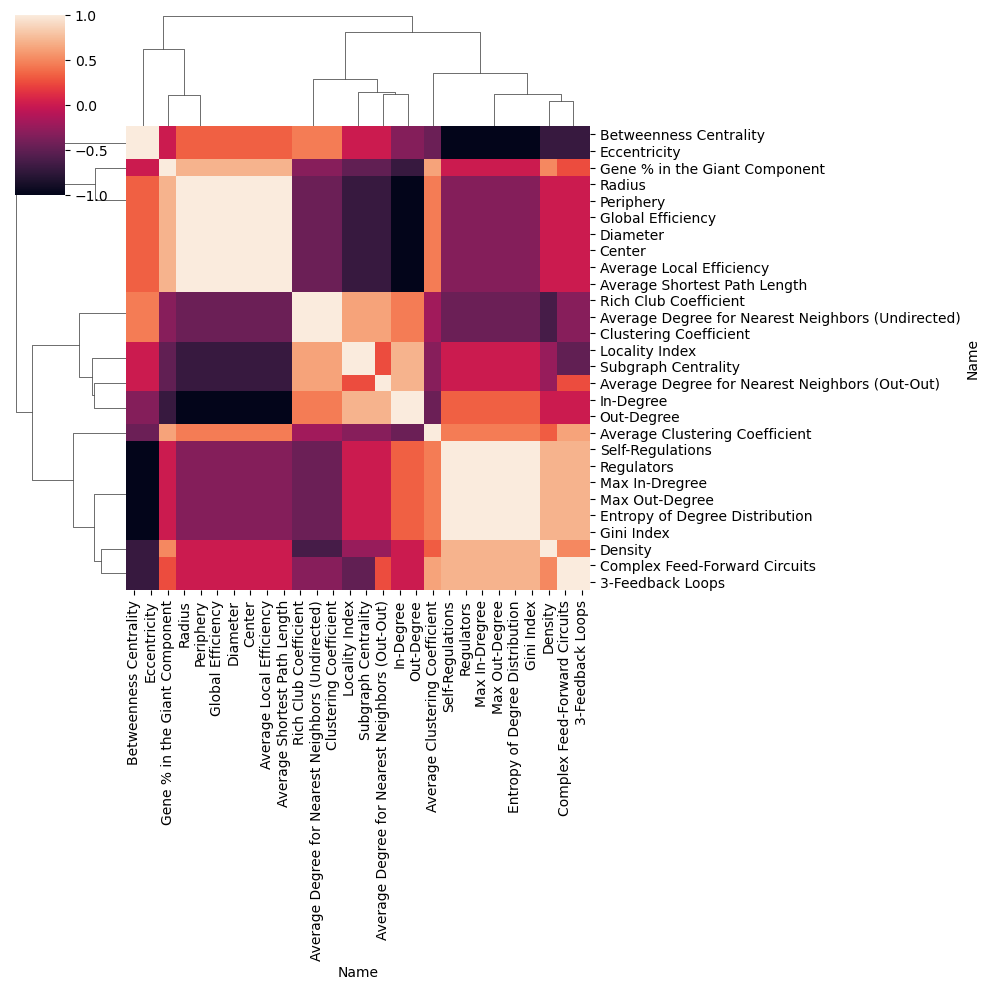

In [23]:
cluster = sb.clustermap(buena)

#### Get props optimizado

In [25]:
def get_props(G, norm=None):

    # Properties that do not use paths object
    instances = get_instances_no_paths(G, child_classes)
    
    # Objetos paths
    remove_self_loops(G)
    G = G.giant_component
    G = G.to_undirected()
    net_shortest_paths = ShortestPaths(G)
    net_shortest_distances = ShortestDistances(G)
    
    # Properties that use paths object
    # They use the giant component from an undirected graph with no selfloops
    instances_paths = get_instances_paths(G, child_classes, net_shortest_paths, net_shortest_distances)
    
    
    instances.update(instances_paths)
    
    scalar_values = {
        name : x.compute()
        for name, x in instances.items()
        if x._return_type == 'scalar'
    }

    dist_values = {
        name : x.compute()
        for name, x in instances.items()
        if x._return_type == 'distribution'
    }

    if norm is not None:
        scalar_values, dist_values = normalize_props(instances, G, norm=norm)
    
    dist_values = {
        k: v for k, v in dist_values.items() if not np.isnan(v).all()
    }

    return scalar_values, dist_values

In [26]:
G = RegNet()
n_nodes = 40
G.add_nodes_from(range(n_nodes))
G.add_edges_from([(i,j) for i in range(n_nodes) for j in range(n_nodes)])

scalar, dist = get_props(G)

<class 'freyrelab.regnets.regnet.RegNet'>


In [27]:
scalar, dist

({'AverageClusteringCoefficient': 1.0,
  'ComplexFeedForwardCircuits': 0,
  'Density': 0.4875,
  'EntropyPKout': 0.0,
  'FeedbackLoops_3': 19760,
  'GenesintheGiantComponent': 40,
  'GiniIndex': -1.0,
  'MaxInDegree': 39,
  'MaxOutDegree': 39,
  'Regulators': 40,
  'SelfRegulations': 0,
  'AverageLocalEfficiency': 1.0,
  'AverageShortestPathLength': 1.0,
  'Center': 40,
  'Diameter': 1,
  'GlobalEfficiency': 1.0,
  'Periphery': 40,
  'Radius': 1},
 {'AverageDegreeNearestNeighbors': array([39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39.,
         39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39.,
         39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39.,
         39.]),
  'AverageOutDegreeNearestNeighbors': array([39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39.,
         39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39.,
         39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39.,
         39.]),
  '